# Network Science - UDD

## Redes Bipartitas


#### *Cristian Candia-Castro Vallejos, Ph.D.*

**Universidad del Desarrollo (UDD), Chile**

- Director at the [Computational Research in Social Sciences Laboratory (CRiSS-Lab)](http://criss-lab.com) 

- Faculty, Data Science Institute, School of Engineering


**Northwestern University, United States**

- External Faculty, Northwestern Institute on Complex Systems (NICO) Kellogg School of Management.


**Capybara Spa (AI & Network Science for Preventive, Traceable School Coexistence Compliance)**

- Founder & Chief Scientific and Technological Officer (CSTO) 
---

# Clase 2 — Redes bipartitas en Python

En este notebook trabajaremos con una red bipartita clásica usando `NetworkX`.

## Objetivos
- cargar una red bipartita real desde una librería de Python;
- identificar sus dos modos;
- construir su matriz de incidencia;
- proyectar la red sobre uno de los modos;
- comparar proyección binaria, proyección ponderada y una proyección filtrada;
- instalar buenas prácticas antes de trabajar con datos masivos.

In [21]:
import networkx as nx
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from networkx.algorithms import bipartite

## 1. Cargar un dataset bipartito

Usaremos el dataset clásico `davis_southern_women_graph()` de `NetworkX`.

### Interpretación
- un modo corresponde a mujeres;
- el otro modo corresponde a eventos;
- una arista indica que una mujer asistió a un evento.

Este tipo de estructura es bipartita porque las conexiones ocurren entre nodos de distinto tipo.

In [22]:
B = nx.davis_southern_women_graph()

print(type(B))
print(f"Número de nodos: {B.number_of_nodes()}")
print(f"Número de aristas: {B.number_of_edges()}")

<class 'networkx.classes.graph.Graph'>
Número de nodos: 32
Número de aristas: 89


## 2. Identificar los dos modos

En una red bipartita, los nodos pertenecen a dos conjuntos disjuntos.

En `NetworkX`, este dataset ya incluye el atributo `bipartite`:
- `bipartite = 0` para un modo;
- `bipartite = 1` para el otro modo.

Separaremos explícitamente ambos conjuntos.

In [24]:
U = {n for n, d in B.nodes(data=True) if d["bipartite"] == 0}
V = {n for n, d in B.nodes(data=True) if d["bipartite"] == 1}

# V = set(B) - U

print(f"Tamaño de U: {len(U)}")
print(f"Tamaño de V: {len(V)}")

print("\nPrimeros nodos de U:")
print(list(U)[:5])

print("\nPrimeros nodos de V:")
print(list(V)[:5])

Tamaño de U: 18
Tamaño de V: 14

Primeros nodos de U:
['Frances Anderson', 'Flora Price', 'Pearl Oglethorpe', 'Laura Mandeville', 'Eleanor Nye']

Primeros nodos de V:
['E8', 'E3', 'E10', 'E6', 'E14']


## 3. Verificar que la red es realmente bipartita

Buena práctica: nunca asumir que la red está bien construida.

Vamos a verificar:
1. que el grafo es bipartito;
2. que no existan enlaces dentro del mismo modo.

In [25]:
print("¿Es bipartita?", bipartite.is_bipartite(B))

# Verificar enlaces U-U y V-V
uu_edges = [(u, v) for u, v in B.edges() if u in U and v in U]
vv_edges = [(u, v) for u, v in B.edges() if u in V and v in V]

print("Enlaces dentro de U:", len(uu_edges))
print("Enlaces dentro de V:", len(vv_edges))

¿Es bipartita? True
Enlaces dentro de U: 0
Enlaces dentro de V: 0


## 4. Inspección básica de la red bipartita

Antes de proyectar, conviene mirar:
- tamaño de ambos modos;
- número de aristas;
- distribución de grados por lado.

Esto ayuda a entender si la red está balanceada o si existe fuerte heterogeneidad entre modos.

In [26]:
deg_U = dict(B.degree(U))
deg_V = dict(B.degree(V))

deg_U_series = pd.Series(deg_U, name="degree_U")
deg_V_series = pd.Series(deg_V, name="degree_V")

print("Resumen grados en U")
print(deg_U_series.describe())

print("\nResumen grados en V")
print(deg_V_series.describe())

Resumen grados en U
count    18.000000
mean      4.944444
std       2.127474
min       2.000000
25%       4.000000
50%       4.000000
75%       7.000000
max       8.000000
Name: degree_U, dtype: float64

Resumen grados en V
count    14.000000
mean      6.357143
std       3.586452
min       3.000000
25%       3.250000
50%       5.500000
75%       8.000000
max      14.000000
Name: degree_V, dtype: float64


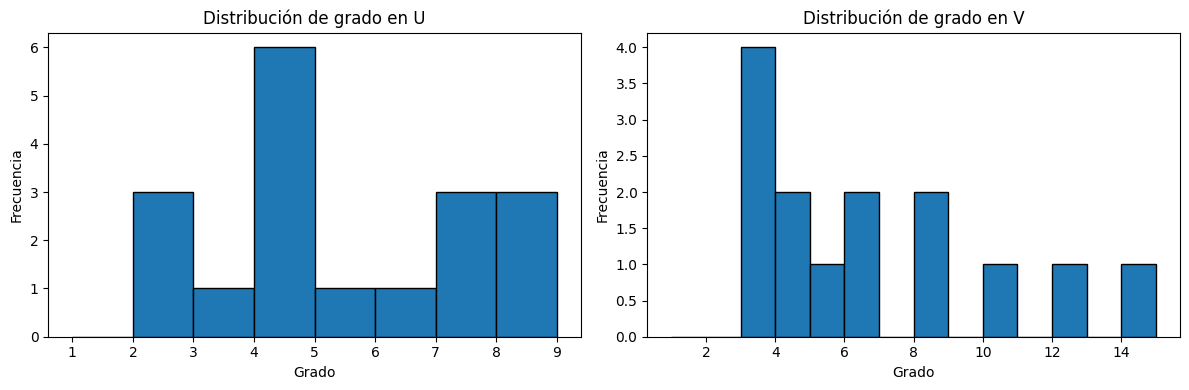

In [27]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].hist(deg_U_series.values, bins=range(1, deg_U_series.max()+2), edgecolor="black")
axes[0].set_title("Distribución de grado en U")
axes[0].set_xlabel("Grado")
axes[0].set_ylabel("Frecuencia")

axes[1].hist(deg_V_series.values, bins=range(1, deg_V_series.max()+2), edgecolor="black")
axes[1].set_title("Distribución de grado en V")
axes[1].set_xlabel("Grado")
axes[1].set_ylabel("Frecuencia")

plt.tight_layout()
plt.show()

## 5. Visualización simple de la estructura bipartita

Para un ejemplo pequeño o mediano, una visualización ayuda a reforzar la intuición:
- nodos de un modo a la izquierda;
- nodos del otro modo a la derecha;
- sólo enlaces cruzados.

En redes masivas, esta visualización deja de ser útil, pero aquí sirve como apoyo conceptual.

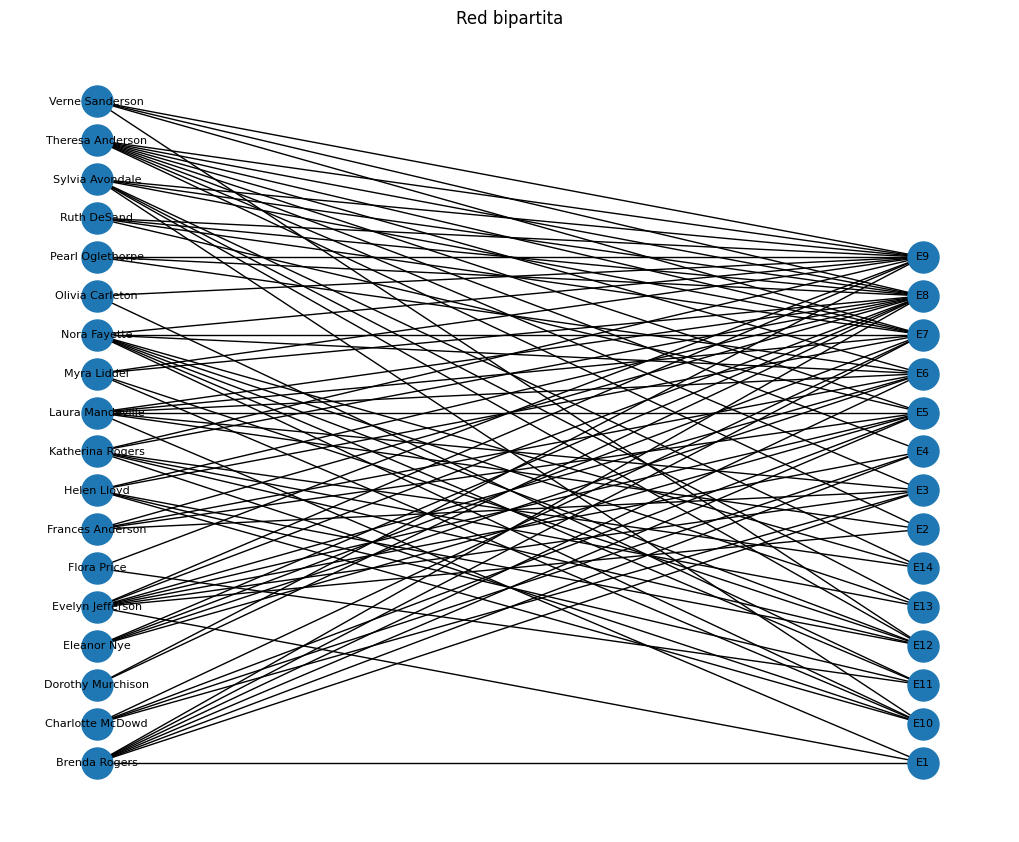

In [28]:
U_sorted = sorted(U)
V_sorted = sorted(V)

pos = {}
pos.update((node, (0, i)) for i, node in enumerate(U_sorted))
pos.update((node, (1, i)) for i, node in enumerate(V_sorted))

plt.figure(figsize=(10, 8))
nx.draw(
    B,
    pos=pos,
    with_labels=True,
    node_size=500,
    font_size=8
)
plt.title("Red bipartita")
plt.axis("off")
plt.show()

## 6. Matriz de incidencia

La representación matricial natural de una red bipartita es su **matriz de incidencia**.

Si proyectamos sobre el modo `U`, conviene ordenar explícitamente filas y columnas:
- filas: nodos de `V`;
- columnas: nodos de `U`.

Así obtenemos una matriz rectangular `M` donde:
- `M[k, i] = 1` si el nodo `v_k` está conectado a `u_i`;
- `M[k, i] = 0` en caso contrario.

In [34]:
M = bipartite.biadjacency_matrix(B, row_order=V_sorted, column_order=U_sorted).toarray()

M_df = pd.DataFrame(M, index=V_sorted, columns=U_sorted)
M_df.iloc[:8, :8]

# M_df.sum(axis=0)#.describe()

,Brenda Rogers,Charlotte McDowd,Dorothy Murchison,Eleanor Nye,Evelyn Jefferson,Flora Price,Frances Anderson,Helen Lloyd
E1,1,0,0,0,1,0,0,0
E10,0,0,0,0,0,0,0,1
E11,0,0,0,0,0,1,0,1
E12,0,0,0,0,0,0,0,1
E13,0,0,0,0,0,0,0,0
E14,0,0,0,0,0,0,0,0
E2,0,0,0,0,1,0,0,0
E3,1,1,0,0,1,0,1,0


## 7. Proyección unipartita sobre un modo

Una proyección sobre `U` conecta dos nodos de `U` si comparten al menos un vecino en `V`.

Hay dos versiones importantes:
- **proyección binaria**: existe o no existe coincidencia;
- **proyección ponderada**: cuántos vecinos comparten.

En términos matriciales:
$P_U = M^\top M$

Fuera de la diagonal, esta matriz cuenta vecinos compartidos.

In [30]:
P = M.T @ M
P_df = pd.DataFrame(P, index=U_sorted, columns=U_sorted)

P_df.iloc[:8, :8]

,Brenda Rogers,Charlotte McDowd,Dorothy Murchison,Eleanor Nye,Evelyn Jefferson,Flora Price,Frances Anderson,Helen Lloyd
Brenda Rogers,7,4,1,4,6,0,4,2
Charlotte McDowd,4,4,0,2,3,0,2,1
Dorothy Murchison,1,0,2,1,2,1,1,1
Eleanor Nye,4,2,1,4,3,0,3,2
Evelyn Jefferson,6,3,2,3,8,1,4,1
Flora Price,0,0,1,0,1,2,0,1
Frances Anderson,4,2,1,3,4,0,4,1
Helen Lloyd,2,1,1,2,1,1,1,5


## 8. Separar diagonal y enlaces reales

La diagonal de $P_U$ contiene el grado bipartito de cada nodo de `U`.

Para analizar la proyección como red:
- la diagonal debe ponerse en cero;
- las entradas fuera de la diagonal pueden interpretarse como pesos.

In [37]:
P_no_diag = P.copy()
np.fill_diagonal(P_no_diag, 0)

P_no_diag_df = pd.DataFrame(P_no_diag, index=U_sorted, columns=U_sorted)
P_no_diag_df#.iloc[:8, :8]

,Brenda Rogers,Charlotte McDowd,Dorothy Murchison,Eleanor Nye,Evelyn Jefferson,Flora Price,Frances Anderson,Helen Lloyd,Katherina Rogers,Laura Mandeville,Myra Liddel,Nora Fayette,Olivia Carleton,Pearl Oglethorpe,Ruth DeSand,Sylvia Avondale,Theresa Anderson,Verne Sanderson
Brenda Rogers,0,4,1,4,6,0,4,2,1,6,1,2,0,2,3,2,6,2
Charlotte McDowd,4,0,0,2,3,0,2,1,0,3,0,1,0,0,2,1,4,1
Dorothy Murchison,1,0,0,1,2,1,1,1,2,1,2,1,1,2,2,2,2,2
Eleanor Nye,4,2,1,0,3,0,3,2,1,4,1,2,0,2,3,2,4,2
Evelyn Jefferson,6,3,2,3,0,1,4,1,2,6,2,2,1,3,3,2,7,2
Flora Price,0,0,1,0,1,0,0,1,1,0,1,2,2,1,1,1,1,1
Frances Anderson,4,2,1,3,4,0,0,1,1,4,1,1,0,2,2,1,4,1
Helen Lloyd,2,1,1,2,1,1,1,0,3,2,3,4,1,1,2,4,2,3
Katherina Rogers,1,0,2,1,2,1,1,3,0,1,4,5,1,2,2,6,2,3
Laura Mandeville,6,3,1,4,6,0,4,2,1,0,1,2,0,2,3,2,6,2


## 9. Construir la proyección binaria y la proyección ponderada con NetworkX

`NetworkX` tiene funciones listas para construir proyecciones:
- `projected_graph`: proyección binaria;
- `weighted_projected_graph`: proyección ponderada por número de vecinos compartidos.

In [38]:
G_bin = bipartite.projected_graph(B, U_sorted)
G_w = bipartite.weighted_projected_graph(B, U_sorted)

print("Proyección binaria")
print(f"Nodos: {G_bin.number_of_nodes()}, Aristas: {G_bin.number_of_edges()}")

print("\nProyección ponderada")
print(f"Nodos: {G_w.number_of_nodes()}, Aristas: {G_w.number_of_edges()}")

Proyección binaria
Nodos: 18, Aristas: 139

Proyección ponderada
Nodos: 18, Aristas: 139


In [39]:
# Mostrar algunas aristas ponderadas
weighted_edges = sorted(
    G_w.edges(data=True),
    key=lambda x: x[2]["weight"],
    reverse=True
)

weighted_edges[:10]

[('Evelyn Jefferson', 'Theresa Anderson', {'weight': 7}),
 ('Brenda Rogers', 'Laura Mandeville', {'weight': 6}),
 ('Brenda Rogers', 'Theresa Anderson', {'weight': 6}),
 ('Brenda Rogers', 'Evelyn Jefferson', {'weight': 6}),
 ('Evelyn Jefferson', 'Laura Mandeville', {'weight': 6}),
 ('Katherina Rogers', 'Sylvia Avondale', {'weight': 6}),
 ('Laura Mandeville', 'Theresa Anderson', {'weight': 6}),
 ('Nora Fayette', 'Sylvia Avondale', {'weight': 6}),
 ('Katherina Rogers', 'Nora Fayette', {'weight': 5}),
 ('Brenda Rogers', 'Frances Anderson', {'weight': 4})]

## 10. Problema: la proyección cruda puede sobrerrepresentar coincidencias triviales

Contar vecinos compartidos es útil, pero tiene una limitación:
- nodos con muchos vecinos tienden a compartir vecinos con muchos otros;
- eso puede inflar la conectividad de la proyección.

Una forma simple de corregir esto es usar una medida normalizada de solapamiento, como **Jaccard**.

In [41]:
def neighbor_sets_from_bipartite(G, nodes):
    return {u: set(G.neighbors(u)) for u in nodes}

neighbors_U = neighbor_sets_from_bipartite(B, U_sorted)

def jaccard_similarity(set_a, set_b):
    inter = len(set_a & set_b)
    union = len(set_a | set_b)
    return inter / union if union > 0 else 0.0

# Construir tabla de similitudes Jaccard para pares en U
rows = []
for i, u in enumerate(U_sorted):
    for j in range(i + 1, len(U_sorted)):
        v = U_sorted[j]
        shared = len(neighbors_U[u] & neighbors_U[v])
        jacc = jaccard_similarity(neighbors_U[u], neighbors_U[v])
        rows.append((u, v, shared, jacc))

jaccard_df = pd.DataFrame(rows, columns=["u", "v", "shared_neighbors", "jaccard"])
jaccard_df.sort_values(["jaccard", "shared_neighbors"], ascending=False).head(10)

jaccard_df

,u,v,shared_neighbors,jaccard
0,Brenda Rogers,Charlotte McDowd,4,0.571429
1,Brenda Rogers,Dorothy Murchison,1,0.125000
2,Brenda Rogers,Eleanor Nye,4,0.571429
3,Brenda Rogers,Evelyn Jefferson,6,0.666667
4,Brenda Rogers,Flora Price,0,0.000000
...,...,...,...,...
148,Ruth DeSand,Theresa Anderson,4,0.500000
149,Ruth DeSand,Verne Sanderson,3,0.600000
150,Sylvia Avondale,Theresa Anderson,3,0.250000
151,Sylvia Avondale,Verne Sanderson,4,0.571429


## 11. Filtrado práctico de una proyección

Antes de analizar una proyección grande, conviene filtrar enlaces poco informativos.

Una regla simple y defendible puede exigir simultáneamente:
- al menos cierto número de vecinos compartidos;
- y una similitud mínima.

Esto no reemplaza un modelo nulo formal, pero sí evita una proyección ingenua y excesivamente densa.

In [42]:
# Umbrales de ejemplo
min_shared = 2
min_jaccard = 0.30

filtered_df = jaccard_df[
    (jaccard_df["shared_neighbors"] >= min_shared) &
    (jaccard_df["jaccard"] >= min_jaccard)
].copy()

filtered_df.sort_values(["jaccard", "shared_neighbors"], ascending=False).head(10)
filtered_df

,u,v,shared_neighbors,jaccard
0,Brenda Rogers,Charlotte McDowd,4,0.571429
2,Brenda Rogers,Eleanor Nye,4,0.571429
3,Brenda Rogers,Evelyn Jefferson,6,0.666667
5,Brenda Rogers,Frances Anderson,4,0.571429
8,Brenda Rogers,Laura Mandeville,6,0.750000
...,...,...,...,...
147,Ruth DeSand,Sylvia Avondale,3,0.375000
148,Ruth DeSand,Theresa Anderson,4,0.500000
149,Ruth DeSand,Verne Sanderson,3,0.600000
151,Sylvia Avondale,Verne Sanderson,4,0.571429


In [43]:
G_filtered = nx.Graph()
G_filtered.add_nodes_from(U_sorted)

for _, row in filtered_df.iterrows():
    G_filtered.add_edge(
        row["u"],
        row["v"],
        shared_neighbors=row["shared_neighbors"],
        jaccard=row["jaccard"]
    )

print(f"Nodos en red filtrada: {G_filtered.number_of_nodes()}")
print(f"Aristas en red filtrada: {G_filtered.number_of_edges()}")

Nodos en red filtrada: 18
Aristas en red filtrada: 61


## 12. Comparar red proyectada cruda vs red filtrada

Esta comparación es importante porque muestra que:
- la proyección cruda puede quedar demasiado densa;
- la red filtrada suele ser más interpretable;
- el filtrado cambia las métricas globales y locales.

En redes grandes, este paso suele ser indispensable antes de pasar a centralidades, comunidades o visualización.

In [44]:
summary = pd.DataFrame({
    "graph": ["binary_projection", "weighted_projection_as_unweighted", "filtered_projection"],
    "n_nodes": [
        G_bin.number_of_nodes(),
        G_w.number_of_nodes(),
        G_filtered.number_of_nodes()
    ],
    "n_edges": [
        G_bin.number_of_edges(),
        G_w.number_of_edges(),
        G_filtered.number_of_edges()
    ],
    "density": [
        nx.density(G_bin),
        nx.density(nx.Graph(G_w)),   # ignorando pesos para densidad
        nx.density(G_filtered)
    ]
})

summary

,graph,n_nodes,n_edges,density
0,binary_projection,18,139,0.908497
1,weighted_projection_as_unweighted,18,139,0.908497
2,filtered_projection,18,61,0.398693


## 13. Centralidades: sólo después de filtrar

Una buena disciplina analítica es:
1. entender la bipartita;
2. construir la proyección;
3. ponderar y filtrar;
4. recién entonces calcular métricas más interpretativas.

Aquí calcularemos grado y betweenness sobre la red filtrada.

In [46]:
degree_dict = dict(G_filtered.degree())
betweenness_dict = nx.betweenness_centrality(G_filtered)

centrality_df = pd.DataFrame({
    "node": list(G_filtered.nodes()),
    "degree": [degree_dict[n] for n in G_filtered.nodes()],
    "betweenness": [betweenness_dict[n] for n in G_filtered.nodes()]
})

centrality_df.sort_values(["degree", "betweenness"], ascending=False)#.head(10)

,node,degree,betweenness
14,Ruth DeSand,12,0.192793
17,Verne Sanderson,10,0.147852
3,Eleanor Nye,9,0.033777
16,Theresa Anderson,9,0.033777
10,Myra Liddel,8,0.049907
13,Pearl Oglethorpe,8,0.041492
4,Evelyn Jefferson,8,0.004412
6,Frances Anderson,8,0.004412
0,Brenda Rogers,7,0.000000
1,Charlotte McDowd,7,0.000000


## 14. Visualización de la red filtrada

La visualización de la proyección filtrada suele ser mucho más útil que la de la proyección cruda.

En este punto ya hemos reducido parte del ruido estructural inducido por coincidencias triviales.

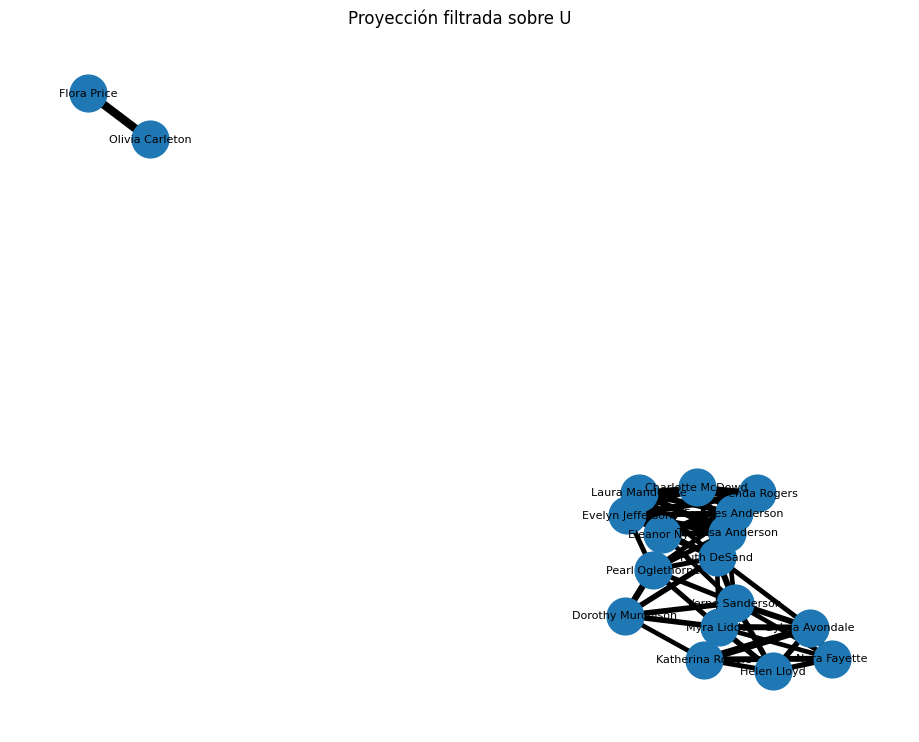

In [47]:
plt.figure(figsize=(9, 7))
pos = nx.spring_layout(G_filtered, seed=42)

edge_widths = [2 + 4 * G_filtered[u][v]["jaccard"] for u, v in G_filtered.edges()]

nx.draw(
    G_filtered,
    pos,
    with_labels=True,
    node_size=700,
    width=edge_widths,
    font_size=8
)

plt.title("Proyección filtrada sobre U")
plt.axis("off")
plt.show()

## 15. Ideas principales

### Qué aprendimos
- la red bipartita debe inspeccionarse como objeto propio;
- la proyección binaria suele ser demasiado grosera;
- la proyección ponderada mejora la representación;
- una similitud normalizada como Jaccard ayuda a corregir por tamaño de vecindarios;
- filtrar antes de analizar hace la red más interpretable.

### Regla metodológica
No interpretar una proyección sin volver a la bipartita que la generó.

## 16. Proyección sobre el otro modo

In [48]:
# Proyección sobre V
G_events_w = bipartite.weighted_projected_graph(B, V_sorted)

weighted_edges_V = sorted(
    G_events_w.edges(data=True),
    key=lambda x: x[2]["weight"],
    reverse=True
)

weighted_edges_V[:10]

[('E8', 'E9', {'weight': 9}),
 ('E7', 'E8', {'weight': 8}),
 ('E5', 'E8', {'weight': 7}),
 ('E6', 'E8', {'weight': 7}),
 ('E3', 'E5', {'weight': 6}),
 ('E5', 'E6', {'weight': 6}),
 ('E5', 'E7', {'weight': 6}),
 ('E10', 'E12', {'weight': 5}),
 ('E12', 'E8', {'weight': 5}),
 ('E12', 'E9', {'weight': 5})]


Una misma bipartita tiene dos proyecciones naturales:
- una sobre `U`;
- otra sobre `V`.

La interpretación sustantiva cambia según el modo sobre el que proyectamos.

## Antes de pasar a un dataset grande

En redes bipartitas pequeñas, podemos inspeccionar visualmente casi todo.

En redes grandes, eso deja de ser posible.

Por eso, antes de trabajar con datos masivos, debemos instalar una pipeline mínima:

1. revisar la estructura bipartita;
2. proyectar ponderado;
3. normalizar coincidencias;
4. filtrar enlaces poco informativos;
5. recién entonces analizar la red resultante.